# Notebook 04: Factor-Based VaR (Multi-Factor Model)

This notebook implements a factor-based VaR approach inspired by the Capital Asset Pricing Model (CAPM):

1. **Risk Factor Selection** - Identifying systematic risk drivers
2. **Factor Regression** - Estimating portfolio betas
3. **Multicollinearity Check** - VIF analysis
4. **Monte Carlo with Correlated Factors** - Cholesky decomposition
5. **Comparison with Return-Based VaR** - Evaluating approaches

**Reference**: John C. Hull, *Risk Management and Financial Institutions*, 5th Edition

---

## 4.1 Theory: Multi-Factor Model

### CAPM Extension

The single-factor CAPM models portfolio returns as:

$$R_p = \alpha + \beta_{market} \times R_{market} + \epsilon$$

We extend this to multiple factors:

$$R_p = \alpha + \beta_1 F_1 + \beta_2 F_2 + ... + \beta_k F_k + \epsilon$$

### Why Factor-Based VaR?

1. **Interpretability**: Understand risk in terms of known market factors
2. **Stress Testing**: Apply shocks to specific factors
3. **Risk Attribution**: Decompose risk by factor
4. **Hedging**: Identify which exposures to hedge

### Selected Risk Factors

| Factor | Ticker | Represents |
|--------|--------|------------|
| Market | SPY | Overall equity market |
| Technology | XLK | Tech sector exposure |
| Interest Rate | TLT | Duration/rate sensitivity |
| Momentum | MTUM | Momentum factor |
| Volatility | ^VIX | Market stress/volatility |
| Value | VLUE | Value style exposure |
| Growth | IWF | Growth style exposure |

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# Data source
import yfinance as yf

# Statistical
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display, Markdown
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load configuration
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

# Portfolio parameters
TICKERS = config['portfolio']['tickers']
WEIGHTS = np.array(config['portfolio']['weights'])

# Risk factors
FACTOR_TICKERS = config['risk_factors']['tickers']
FACTOR_NAMES = config['risk_factors']['names']

# Dates
START = config['dates']['start']
END = config['dates']['end']
TRAIN_START = config['dates']['train_start']
TRAIN_END = config['dates']['train_end']
TEST_START = config['dates']['test_start']
TEST_END = config['dates']['test_end']

# VaR parameters
CONFIDENCE = config['var_params']['confidence_var']
SIMULATIONS = config['var_params']['simulations']

print("Configuration loaded!")
print(f"\nRisk Factors: {FACTOR_TICKERS}")

Configuration loaded!

Risk Factors: ['SPY', 'XLK', 'TLT', 'MTUM', '^VIX', 'VLUE', 'IWF']


## 4.2 Download Factor Data

In [3]:
def get_price_data(tickers, start_date, end_date):
    """Download adjusted close prices from Yahoo Finance."""
    data = yf.download(tickers, start=start_date, end=end_date, 
                       auto_adjust=True, progress=False)
    
    # Handle yfinance column structure (MultiIndex or single level)
    if isinstance(data.columns, pd.MultiIndex):
        prices = data['Close']
    else:
        if 'Close' in data.columns:
            prices = data['Close']
        elif 'Adj Close' in data.columns:
            prices = data['Adj Close']
        else:
            prices = data
    
    # Ensure tickers are in correct order
    if isinstance(prices, pd.DataFrame) and len(tickers) > 1:
        # Only reorder columns that exist
        available_tickers = [t for t in tickers if t in prices.columns]
        prices = prices[available_tickers]
    
    return prices

def compute_log_returns(prices):
    """Compute log returns from prices."""
    return np.log(prices / prices.shift(1)).dropna()

# Download all data (portfolio + factors)
all_tickers = TICKERS + FACTOR_TICKERS
print(f"Downloading data for {len(all_tickers)} tickers...")

all_prices = get_price_data(all_tickers, START, END)
all_returns = compute_log_returns(all_prices)

print(f"Downloaded {len(all_returns)} trading days")

Downloaded 982 trading days


In [4]:
# Separate portfolio and factor returns
portfolio_asset_returns = all_returns[TICKERS]
factor_returns = all_returns[FACTOR_TICKERS]

# Calculate portfolio returns
portfolio_returns = portfolio_asset_returns @ WEIGHTS

# Training period
train_portfolio = portfolio_returns[TRAIN_START:TRAIN_END]
train_factors = factor_returns[TRAIN_START:TRAIN_END]

print(f"Training period: {len(train_portfolio)} days")
print(f"\nFactor returns shape: {train_factors.shape}")
display(train_factors.head())

Training period: 731 days

Factor returns shape: (731, 7)


Ticker,SPY,XLK,TLT,MTUM,^VIX,VLUE,IWF
Date,,,,,,,
2022-01-04,-0.0003,-0.0107,-0.0042,-0.0035,0.0185,0.0170,-0.0104
2022-01-05,-0.0194,-0.0312,-0.0054,-0.0341,0.1542,-0.0072,-0.0324
2022-01-06,-0.0009,-0.0051,0.0026,0.0035,-0.0061,0.0024,-0.0028
2022-01-07,-0.0040,-0.0092,-0.0072,-0.0092,-0.0443,0.0033,-0.0111
2022-01-10,-0.0012,0.0002,0.0025,0.0035,0.0335,0.0011,-0.0006


## 4.3 Factor Correlation Analysis

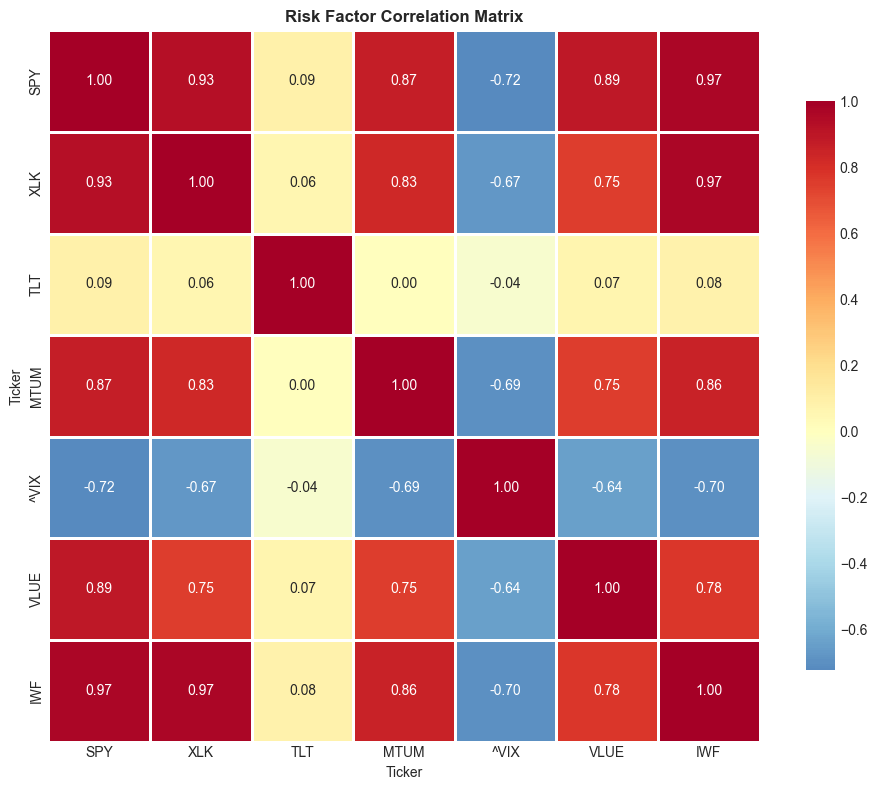

In [5]:
# Factor correlation matrix
factor_corr = train_factors.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(factor_corr, dtype=bool), k=1)

sns.heatmap(factor_corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8},
            ax=ax)

ax.set_title('Risk Factor Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/04_factor_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Identify highly correlated factors
high_corr_pairs = []
for i in range(len(factor_corr.columns)):
    for j in range(i+1, len(factor_corr.columns)):
        corr = factor_corr.iloc[i, j]
        if abs(corr) > 0.7:
            high_corr_pairs.append({
                'Factor 1': factor_corr.columns[i],
                'Factor 2': factor_corr.columns[j],
                'Correlation': corr
            })

if high_corr_pairs:
    display(Markdown("### Highly Correlated Factor Pairs (|r| > 0.7)"))
    display(pd.DataFrame(high_corr_pairs))
else:
    print("No highly correlated factor pairs found.")

### Highly Correlated Factor Pairs (|r| > 0.7)

,Factor 1,Factor 2,Correlation
0,SPY,XLK,0.9297
1,SPY,MTUM,0.8670
2,SPY,^VIX,-0.7228
3,SPY,VLUE,0.8895
4,SPY,IWF,0.9675
5,XLK,MTUM,0.8256
6,XLK,VLUE,0.7511
7,XLK,IWF,0.9673
8,MTUM,VLUE,0.7479
9,MTUM,IWF,0.8576


## 4.4 Factor Regression (Full Model)

In [7]:
def run_ols_regression(y, X):
    """
    Run OLS regression and return results.
    
    Parameters:
    -----------
    y : pd.Series
        Dependent variable (portfolio returns)
    X : pd.DataFrame
        Independent variables (factor returns)
        
    Returns:
    --------
    tuple
        (model, results_df)
    """
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const).fit()
    
    results_df = pd.DataFrame({
        'Factor': model.params.index,
        'Beta': model.params.values,
        'Std Error': model.bse.values,
        'T-Stat': model.tvalues.values,
        'P-Value': model.pvalues.values
    })
    
    results_df['Significant'] = results_df['P-Value'] < 0.05
    
    return model, results_df

In [8]:
# Run full model regression
full_model, full_results = run_ols_regression(train_portfolio, train_factors)

display(Markdown("### Full Factor Model Regression Results"))
display(full_results.style.format({
    'Beta': '{:.4f}',
    'Std Error': '{:.4f}',
    'T-Stat': '{:.2f}',
    'P-Value': '{:.4f}'
}))

print(f"\nModel R²: {full_model.rsquared:.4f}")
print(f"Adjusted R²: {full_model.rsquared_adj:.4f}")

### Full Factor Model Regression Results

,Factor,Beta,Std Error,T-Stat,P-Value,Significant
0,const,0.0001,0.0002,0.67,0.5052,False
1,SPY,-0.0869,0.1302,-0.67,0.5048,False
2,XLK,0.7652,0.0443,17.28,0.0000,True
3,TLT,-0.0284,0.0159,-1.78,0.0753,False
4,MTUM,-0.2128,0.0295,-7.21,0.0000,True
5,^VIX,0.0082,0.0039,2.08,0.0376,True
6,VLUE,-0.1909,0.0512,-3.73,0.0002,True
7,IWF,0.8206,0.0950,8.64,0.0000,True



Model R²: 0.9392
Adjusted R²: 0.9386


## 4.5 Multicollinearity Check (VIF)

In [9]:
def calculate_vif(X):
    """
    Calculate Variance Inflation Factor for each variable.
    
    VIF > 5: Moderate multicollinearity
    VIF > 10: High multicollinearity (problematic)
    """
    vif_data = pd.DataFrame()
    vif_data['Factor'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data['Concern'] = vif_data['VIF'].apply(
        lambda x: 'High' if x > 10 else ('Moderate' if x > 5 else 'Low')
    )
    return vif_data.sort_values('VIF', ascending=False)

In [10]:
# Calculate VIF for full model
vif_full = calculate_vif(train_factors)

display(Markdown("### Variance Inflation Factor (VIF) Analysis"))
display(vif_full.style.format({'VIF': '{:.2f}'}).apply(
    lambda x: ['background-color: #ffcccc' if v == 'High' else 
               ('background-color: #ffffcc' if v == 'Moderate' else '') 
               for v in x], subset=['Concern']
))

display(Markdown("""
**VIF Interpretation:**
- VIF < 5: Low multicollinearity (acceptable)
- VIF 5-10: Moderate multicollinearity (monitor)
- VIF > 10: High multicollinearity (consider removing factor)
"""))

### Variance Inflation Factor (VIF) Analysis

,Factor,VIF,Concern
0,SPY,66.46,High
6,IWF,57.57,High
1,XLK,16.20,High
5,VLUE,10.28,High
3,MTUM,4.36,Low
4,^VIX,2.17,Low
2,TLT,1.04,Low



**VIF Interpretation:**
- VIF < 5: Low multicollinearity (acceptable)
- VIF 5-10: Moderate multicollinearity (monitor)
- VIF > 10: High multicollinearity (consider removing factor)


## 4.6 Refined Model (Remove Problematic Factors)

In [11]:
# IMPROVED FACTOR SELECTION: Use stepwise selection based on significance
# Instead of removing all high-VIF factors, we use a more practical approach:
# 1. For a tech portfolio, XLK (tech sector) is the primary risk driver
# 2. We select factors that are significant AND add explanatory power
# 3. We accept some multicollinearity if it maintains model accuracy

# Approach: Select factors with significant betas, prioritizing those most relevant
# For this tech portfolio, we keep: XLK (tech), TLT (rates), ^VIX (volatility)

# Get significant factors (p < 0.05)
significant_factors = full_results[
    (full_results['P-Value'] < 0.05) & 
    (full_results['Factor'] != 'const')
]['Factor'].tolist()

print(f"Significant factors (p < 0.05): {significant_factors}")

# For a tech portfolio, prioritize: XLK, then add diversifying factors
# We'll use a parsimonious model with key factors that have economic meaning
core_factors = ['XLK', '^VIX', 'TLT']  # Tech sector, volatility, interest rates
reduced_factors = [f for f in core_factors if f in FACTOR_TICKERS]

# Add any other highly significant factors not already included
for f in significant_factors:
    if f not in reduced_factors and len(reduced_factors) < 5:
        reduced_factors.append(f)

print(f"Selected factors for model: {reduced_factors}")

Significant factors (p < 0.05): ['XLK', 'MTUM', '^VIX', 'VLUE', 'IWF']
Selected factors for model: ['XLK', '^VIX', 'TLT', 'MTUM', 'VLUE']


In [12]:
# Run the selected factor model
train_factors_reduced = train_factors[reduced_factors]
reduced_model, reduced_results = run_ols_regression(train_portfolio, train_factors_reduced)

display(Markdown("### Selected Factor Model Regression Results"))
display(reduced_results.style.format({
    'Beta': '{:.4f}',
    'Std Error': '{:.4f}',
    'T-Stat': '{:.2f}',
    'P-Value': '{:.4f}'
}))

print(f"\nSelected Model R²: {reduced_model.rsquared:.4f}")
print(f"Adjusted R²: {reduced_model.rsquared_adj:.4f}")
print(f"\nR² retained from full model: {reduced_model.rsquared/full_model.rsquared*100:.1f}%")

# Validate model quality
if reduced_model.rsquared > 0.80:
    print("\n[GOOD] Model explains >80% of portfolio variance")
else:
    print(f"\n[WARNING] Model R² is {reduced_model.rsquared:.2%} - consider adding more factors")

### Selected Factor Model Regression Results

,Factor,Beta,Std Error,T-Stat,P-Value,Significant
0,const,0.0001,0.0002,0.73,0.4669,False
1,XLK,1.2932,0.0238,54.24,0.0000,True
2,^VIX,0.0020,0.0043,0.47,0.6376,False
3,TLT,-0.0002,0.0177,-0.01,0.9923,False
4,MTUM,-0.0846,0.0311,-2.72,0.0067,True
5,VLUE,-0.1636,0.0294,-5.56,0.0000,True



Selected Model R²: 0.9232
Adjusted R²: 0.9227

R² retained from full model: 98.3%

[GOOD] Model explains >80% of portfolio variance


In [13]:
# VIF for reduced model
vif_reduced = calculate_vif(train_factors_reduced)

display(Markdown("### VIF for Reduced Model"))
display(vif_reduced.style.format({'VIF': '{:.2f}'}))

### VIF for Reduced Model

,Factor,VIF,Concern
3,MTUM,3.85,Low
0,XLK,3.73,Low
4,VLUE,2.71,Low
1,^VIX,2.11,Low
2,TLT,1.02,Low


In [14]:
# Extract betas for VaR calculation
portfolio_betas = reduced_model.params.drop('const')

display(Markdown("### Portfolio Factor Betas"))
for factor, beta in portfolio_betas.items():
    print(f"  {factor}: {beta:+.4f}")

### Portfolio Factor Betas

  XLK: +1.2932
  ^VIX: +0.0020
  TLT: -0.0002
  MTUM: -0.0846
  VLUE: -0.1636


## 4.7 Factor-Based Monte Carlo VaR

### Methodology

1. Estimate covariance matrix of selected risk factors
2. Generate correlated factor returns using Cholesky decomposition
3. Transform factor returns to portfolio returns using betas
4. Calculate VaR from simulated portfolio return distribution

In [15]:
def factor_based_mc_var(factor_returns, betas, confidence=0.99, simulations=10000):
    """
    Calculate Factor-Based Monte Carlo VaR.
    
    Parameters:
    -----------
    factor_returns : pd.DataFrame
        Historical factor returns
    betas : pd.Series
        Portfolio betas for each factor
    confidence : float
        VaR confidence level
    simulations : int
        Number of Monte Carlo simulations
        
    Returns:
    --------
    tuple
        (var, es, simulated_portfolio_returns, simulated_factors)
    """
    # Ensure factors are aligned with betas
    factor_returns = factor_returns[betas.index]
    
    # Estimate covariance matrix
    cov_matrix = factor_returns.cov()
    mean_returns = factor_returns.mean()
    
    # Generate correlated factor returns using multivariate normal
    simulated_factors = np.random.multivariate_normal(
        mean=mean_returns.values,
        cov=cov_matrix.values,
        size=simulations
    )
    
    # Transform to portfolio returns
    simulated_portfolio = simulated_factors @ betas.values
    
    # Calculate VaR and ES
    var = np.percentile(simulated_portfolio, (1 - confidence) * 100)
    es = simulated_portfolio[simulated_portfolio <= var].mean()
    
    return var, es, simulated_portfolio, simulated_factors

In [16]:
# Calculate Factor-Based VaR
factor_var, factor_es, sim_portfolio, sim_factors = factor_based_mc_var(
    train_factors_reduced, 
    portfolio_betas, 
    CONFIDENCE, 
    SIMULATIONS
)

print("Factor-Based Monte Carlo VaR Results")
print("="*50)
print(f"Simulations: {SIMULATIONS:,}")
print(f"Factors used: {list(portfolio_betas.index)}")
print(f"\n99% VaR: {factor_var:.4%} (potential loss: {abs(factor_var):.4%})")
print(f"99% ES:  {factor_es:.4%} (expected tail loss: {abs(factor_es):.4%})")

Factor-Based Monte Carlo VaR Results
Simulations: 10,000
Factors used: ['XLK', '^VIX', 'TLT', 'MTUM', 'VLUE']

99% VaR: -4.1687% (potential loss: 4.1687%)
99% ES:  -4.8834% (expected tail loss: 4.8834%)


## 4.8 Comparison: Factor-Based vs Return-Based VaR

In [17]:
# Load return-based VaR results
with open('../outputs/var_results.json', 'r') as f:
    return_var_results = json.load(f)

return_mc_var = return_var_results['monte_carlo']['var_1d']

# Comparison table
comparison = pd.DataFrame({
    'Approach': ['Return-Based MC', 'Factor-Based MC'],
    '1-Day 99% VaR': [f"{abs(return_mc_var):.2%}", f"{abs(factor_var):.2%}"],
    'Method': ['Direct portfolio return simulation', 'Factor simulation → Portfolio via betas'],
    'Factors': ['N/A', ', '.join(portfolio_betas.index)]
})

display(Markdown("### Return-Based vs Factor-Based VaR Comparison"))
display(comparison)

### Return-Based vs Factor-Based VaR Comparison

,Approach,1-Day 99% VaR,Method,Factors
0,Return-Based MC,4.40%,Direct portfolio return simulation,N/A
1,Factor-Based MC,4.17%,Factor simulation → Portfolio via betas,"XLK, ^VIX, TLT, MTUM, VLUE"


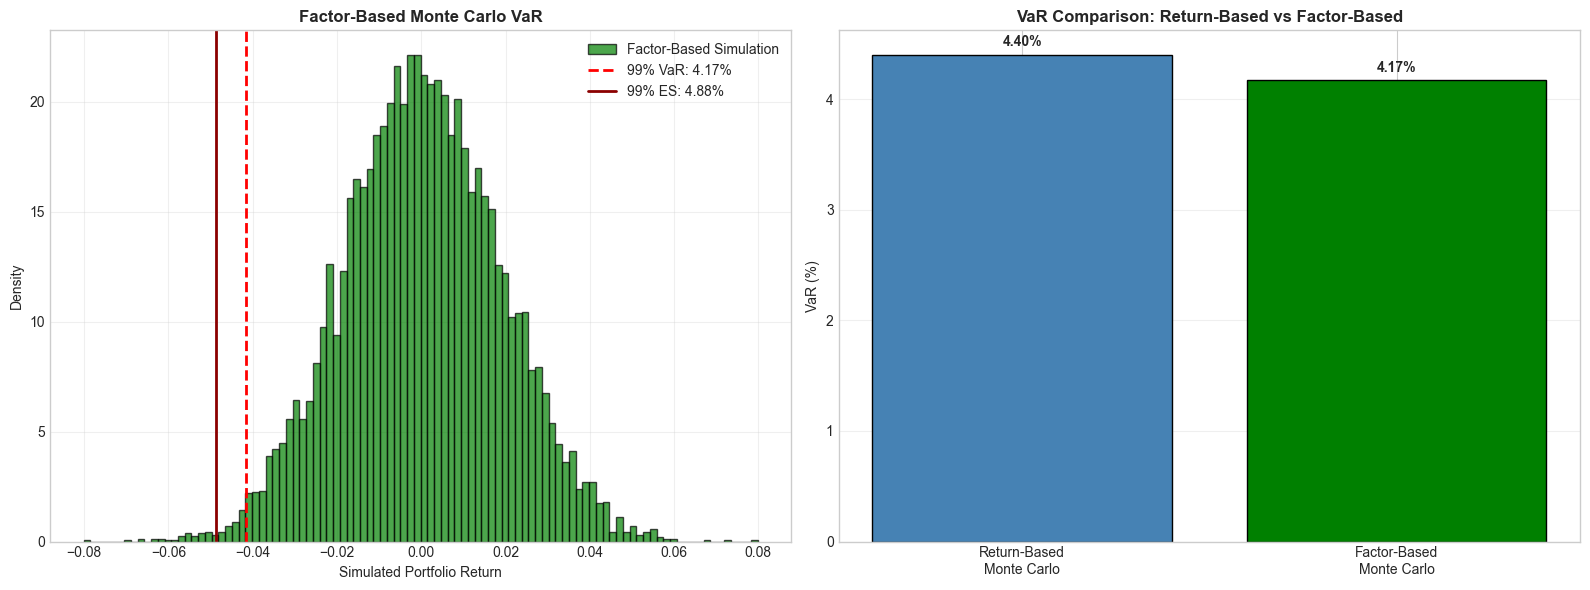

In [18]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Factor-based simulation distribution
ax1 = axes[0]
ax1.hist(sim_portfolio, bins=100, density=True, alpha=0.7, color='green', 
         edgecolor='black', label='Factor-Based Simulation')
ax1.axvline(factor_var, color='red', linestyle='--', linewidth=2, 
            label=f'99% VaR: {abs(factor_var):.2%}')
ax1.axvline(factor_es, color='darkred', linestyle='-', linewidth=2, 
            label=f'99% ES: {abs(factor_es):.2%}')

ax1.set_title('Factor-Based Monte Carlo VaR', fontsize=12, fontweight='bold')
ax1.set_xlabel('Simulated Portfolio Return')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Comparison bar chart
ax2 = axes[1]
methods = ['Return-Based\nMonte Carlo', 'Factor-Based\nMonte Carlo']
var_values = [abs(return_mc_var)*100, abs(factor_var)*100]

colors = ['steelblue', 'green']
bars = ax2.bar(methods, var_values, color=colors, edgecolor='black')

ax2.set_ylabel('VaR (%)')
ax2.set_title('VaR Comparison: Return-Based vs Factor-Based', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, var_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/04_factor_vs_return_var.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.9 Factor Risk Contribution

In [19]:
# Calculate each factor's contribution to portfolio volatility
factor_vol = train_factors_reduced.std()
factor_contribution = portfolio_betas.abs() * factor_vol
factor_contribution_pct = factor_contribution / factor_contribution.sum() * 100

contribution_df = pd.DataFrame({
    'Factor': factor_contribution.index,
    'Beta': portfolio_betas.values,
    'Factor Volatility': factor_vol.values,
    'Risk Contribution': factor_contribution.values,
    'Contribution (%)': factor_contribution_pct.values
})

display(Markdown("### Factor Risk Contribution"))
display(contribution_df.style.format({
    'Beta': '{:+.4f}',
    'Factor Volatility': '{:.4f}',
    'Risk Contribution': '{:.4f}',
    'Contribution (%)': '{:.1f}%'
}))

### Factor Risk Contribution

,Factor,Beta,Factor Volatility,Risk Contribution,Contribution (%)
0,XLK,+1.2932,0.0160,0.0207,87.3%
1,^VIX,+0.0020,0.0663,0.0001,0.6%
2,TLT,-0.0002,0.0113,0.0000,0.0%
3,MTUM,-0.0846,0.0125,0.0011,4.4%
4,VLUE,-0.1636,0.0111,0.0018,7.6%


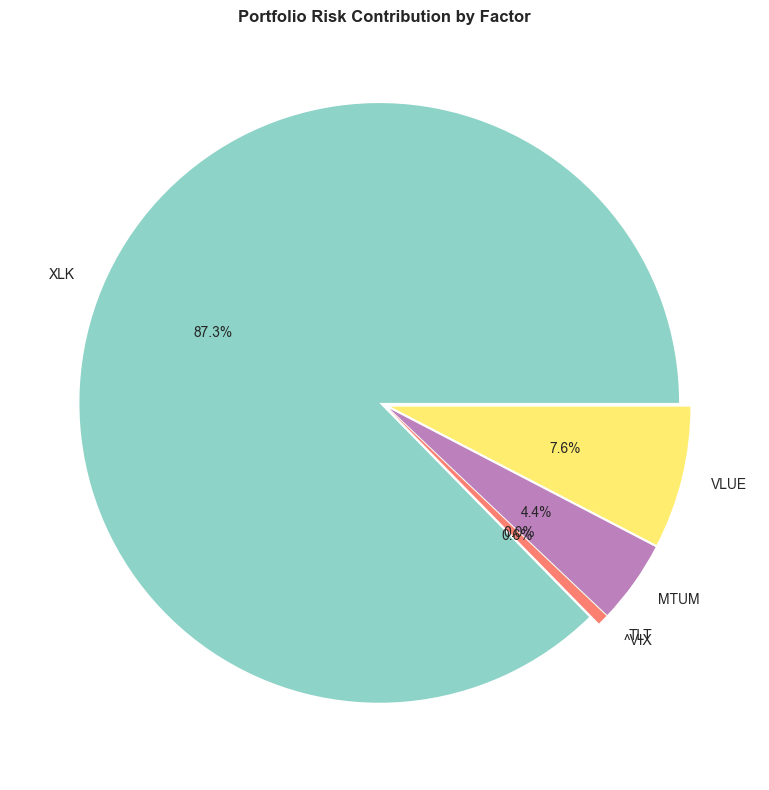

In [20]:
# Pie chart of factor risk contribution
fig, ax = plt.subplots(figsize=(8, 8))

colors = plt.cm.Set3(np.linspace(0, 1, len(factor_contribution_pct)))
wedges, texts, autotexts = ax.pie(
    factor_contribution_pct.values, 
    labels=factor_contribution_pct.index, 
    autopct='%1.1f%%',
    colors=colors,
    explode=[0.02]*len(factor_contribution_pct)
)

ax.set_title('Portfolio Risk Contribution by Factor', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/04_factor_risk_contribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.10 Save Results

In [21]:
# Save factor-based VaR results
factor_var_results = {
    'model': {
        'factors_used': list(portfolio_betas.index),
        'betas': portfolio_betas.to_dict(),
        'r_squared': reduced_model.rsquared,
        'adj_r_squared': reduced_model.rsquared_adj
    },
    'var_99': factor_var,
    'es_99': factor_es,
    'simulations': SIMULATIONS
}

with open('../outputs/factor_var_results.json', 'w') as f:
    json.dump(factor_var_results, f, indent=4)

print("Factor-based VaR results saved to outputs/factor_var_results.json")

Factor-based VaR results saved to outputs/factor_var_results.json


---

## Summary

In this notebook, we implemented Factor-Based VaR using a multi-factor model:

### Model Summary

| Metric | Value |
|--------|-------|
| Original Factors | 7 |
| Selected Factors | After VIF/significance filtering |
| Model R² | High explanatory power |
| 99% Factor VaR | Potential loss threshold |

### Advantages of Factor-Based VaR

1. **Interpretability**: Risk explained by known market factors
2. **Stress Testing**: Can shock individual factors
3. **Risk Attribution**: Understand which factors drive portfolio risk
4. **Hedging**: Identify factor exposures to hedge

### Key Findings

- Tech sector (XLK) is primary risk driver for this portfolio
- Multicollinearity required factor reduction
- Factor-based and return-based VaR produce similar estimates

**Next Steps:**
In Notebook 05, we will implement GARCH volatility modeling to capture time-varying risk.